# Machine Learning Models

El propósito del siguiente notebook es probar modelos de Machine Learning (XGBoost, RandomForest y Long Short Term Memory) para predecir el último año registrado del valor semanal de los casos de depresión que se tienen desde 2014. 

Se prueban modelos base con la base de datos sin variables exógenas y solo añadiendo lags y algunas variables temporales de la base de datos inicial. Posteriormente, se van agregando variables exógenas para evaluar su peso en la variable objetivo ("valor"), tales como las fechas de covid. También se prueba el entrenamiento del modelo con logaritmo para estabilizar resultados. 
Las métricas que fueron de utilidad para evaluar los modelos fueron RMSE y MAE, que se compararon de Train y Test. 
También se agregan gráficas que ayudan a visualizar el funcionamiento del modelo, features de importancia y funciones de walk forward de 4 bloques para evaluar qué tan bien está aprendiendo el modelo. 

### Libraries + Load df

In [183]:
import sys
sys.path.append('../../')

In [184]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.utils import helpers as func
import prince as pr
import plotly.express as px
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [185]:
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.
Dimensiones del DataFrame: (573, 11)

Primeras filas del DataFrame:


,fecha,valor_acumulado,semana,rolling_mean,rolling_std,upper_bound,lower_bound,is_outlier,valor_acumulado_corregido,mes,año
0,2014-01-06,131.0,2,NaN,NaN,NaN,NaN,False,131.0,1,2014
1,2014-01-13,789.0,3,NaN,NaN,NaN,NaN,False,789.0,1,2014
2,2014-01-20,1722.0,4,880.666667,799.451270,1999.898445,-238.565112,False,1722.0,1,2014
3,2014-01-27,2745.0,5,1346.750000,1137.987807,2939.932930,-246.432930,False,2745.0,1,2014
4,2014-02-03,3896.0,6,2288.000000,1336.895658,4159.653921,416.346079,False,3896.0,2,2014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      573 non-null    datetime64[ns]
 1   valor_acumulado            573 non-null    float64       
 2   semana                     573 non-null    UInt32        
 3   rolling_mean               571 non-null    float64       
 4   rolling_std                571 non-null    float64       
 5   upper_bound                571 non-null    float64       
 6   lower_bound                571 non-null    float64       
 7   is_outlier                 573 non-null    bool          
 8   valor_acumulado_corregido  573 non-null    float64       
 9   mes                        573 non-null    int32         
 10  año                        573 non-null    int32         
dtypes: UInt32(1), bool(1), datetime64[ns](1), float64(6), int32(2)
memory u

None

### Utilidad

In [186]:
def temporal_split(df, test_weeks=52):
    df_ = df.sort_values("fecha").reset_index(drop=True)
    return df_.iloc[:-test_weeks], df_.iloc[-test_weeks:]

def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def plot_last_year(df_test, y_test, y_pred, title):
    plt.figure(figsize=(14,5))
    plt.plot(df_test["fecha"], y_test, label="Real", color="steelblue", linewidth=2)
    plt.plot(df_test["fecha"], y_pred, '--', label="Predicho", color="darkorange", linewidth=2)
    plt.title(title); plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
    plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()
    
def feature_importance_xgb(model, feature_names, top=15):
    imp = model.get_score(importance_type="gain")
    imp = pd.DataFrame({"feature": list(imp.keys()), "gain": list(imp.values())})
    imp = imp.sort_values("gain", ascending=False).head(top)
    display(imp)
    imp.plot.barh(x="feature", y="gain", figsize=(8,5), title="Importancia (XGB, gain)"); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

def feature_importance_rf(model, feature_names, top=15):
    imp = pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).head(top)
    display(imp)
    imp.plot.barh(x="feature", y="importance", figsize=(8,5), title="Importancia (RF)"); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
    
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    rmses, maes = [], []
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        rmse = np.sqrt(mean_squared_error(real, pred))
        mae  = mean_absolute_error(real, pred)
        rmses.append(rmse); maes.append(mae)
        if verbose:
            print(f"Bloque {i+1} -> MAE={mae:.1f} RMSE={rmse:.1f}  (best_iter={model.best_iteration})")

    return np.mean(maes), np.mean(rmses), maes, rmses

In [187]:
# Crear variable "valor" = incremento semanal del valor acumulado
df['valor'] = df['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df['valor'] = df['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df['valor'] = df['valor'].astype(float)

In [188]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

In [189]:
for lag in [1, 4, 12, 26, 52]:
    df[f'lag_{lag}'] = df['valor'].shift(lag)
df = df.dropna().reset_index(drop=True)
#print(df.info())

## XGBoost

### Base XGB Model

In [190]:
df_xgb = df.copy()
target = 'valor' 
features = [col for col in df_xgb.columns if col not in ['fecha', 'valor_acumulado', 
                                                     'valor_acumulado_corregido', 
                                                     'is_outlier']]

test_size = 52  # un año para prueba
train_df, test_df = temporal_split(df_xgb, test_weeks=test_size)

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]


In [191]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)


params1 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 2,
    "alpha": 1,
    "seed": 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

base_model = xgb.train(
    params=params1,
    dtrain=dtrain,
    num_boost_round=4000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)
y_pred_train = base_model.predict(xgb.DMatrix(X_train), iteration_range=(0, base_model.best_iteration + 1))
y_pred_test = base_model.predict(xgb.DMatrix(X_test), iteration_range=(0, base_model.best_iteration + 1))

mae_train, rmse_train = eval_mae_rmse(y_train, y_pred_train)
mae_test, rmse_test = eval_mae_rmse(y_test, y_pred_test)
print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

[0]	train-rmse:536.15473	test-rmse:752.32771
[100]	train-rmse:342.37365	test-rmse:466.93957
[200]	train-rmse:223.14021	test-rmse:293.06632
[300]	train-rmse:149.94319	test-rmse:182.69058
[400]	train-rmse:105.00705	test-rmse:115.11068
[500]	train-rmse:76.70623	test-rmse:75.24571
[600]	train-rmse:58.38961	test-rmse:51.03261
[700]	train-rmse:46.24799	test-rmse:35.46771
[800]	train-rmse:37.57451	test-rmse:25.50847
[900]	train-rmse:31.05646	test-rmse:18.91923
[1000]	train-rmse:25.94749	test-rmse:14.93793
[1100]	train-rmse:21.82966	test-rmse:12.41326
[1200]	train-rmse:18.45593	test-rmse:10.85336
[1300]	train-rmse:15.65817	test-rmse:10.39016
[1400]	train-rmse:13.32425	test-rmse:10.12291
[1500]	train-rmse:11.36783	test-rmse:9.94063
[1600]	train-rmse:9.72986	test-rmse:9.79356
[1700]	train-rmse:8.36115	test-rmse:9.73365
[1800]	train-rmse:7.22224	test-rmse:9.65726
[1846]	train-rmse:6.76173	test-rmse:9.68514
Train -> MAE=2.21  RMSE=7.25
Test  -> MAE=7.18  RMSE=9.66


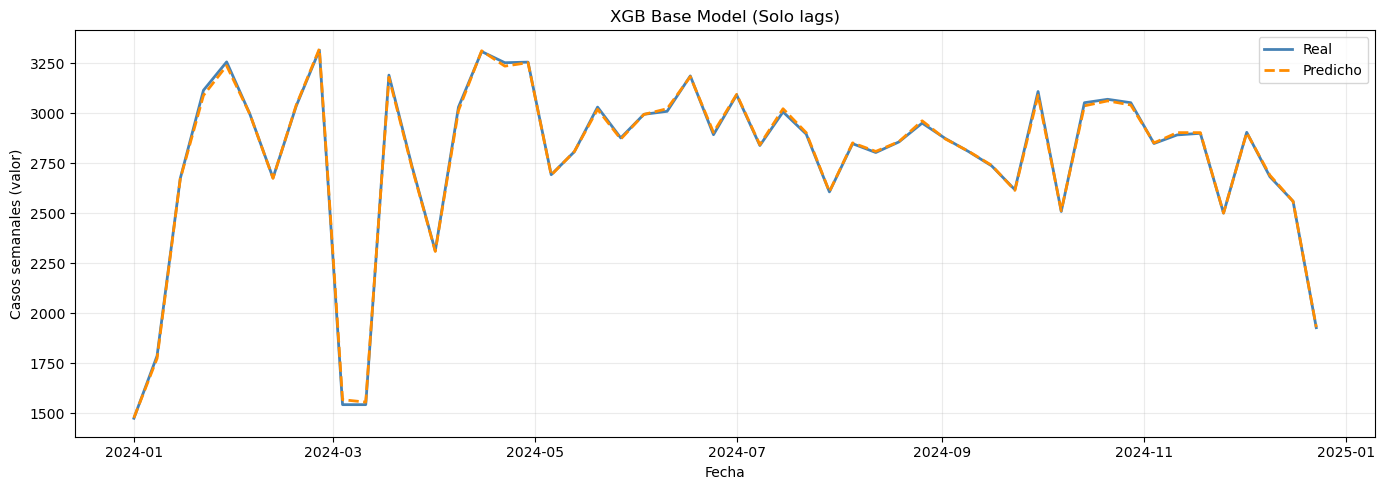

In [192]:
plot_last_year(
    df_xgb.iloc[-len(y_pred_test):],         
    y_test.values,   # valores reales
    y_pred_test,          # valores predichos
    title="XGB Base Model (Solo lags)"
)

,feature,gain
7,valor,713466.250000
3,upper_bound,4049.593018
2,rolling_std,869.772583
1,rolling_mean,286.426147
4,lower_bound,147.083618
11,lag_4,111.616241
10,lag_1,104.925758
9,mes_cos,102.699043
12,lag_12,95.690201
8,mes_sin,91.867981


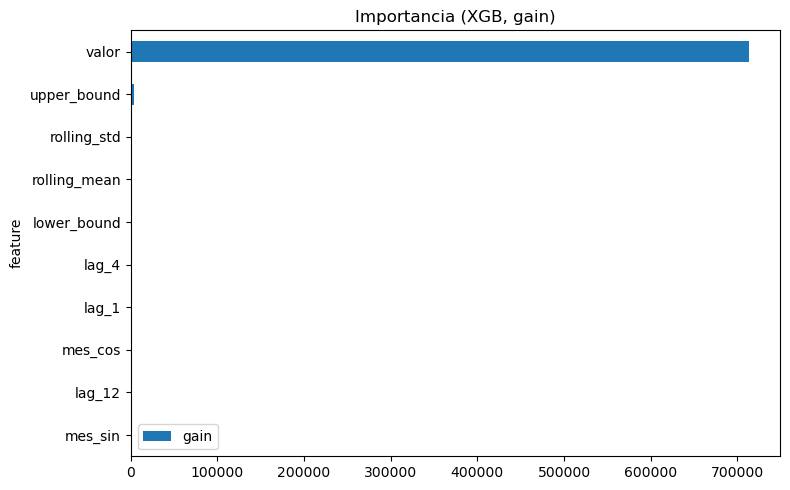

In [193]:
feature_importance_xgb(base_model, features, top=10)

### Model 1

In [194]:
train_df['valor_log'] = np.log1p(train_df['valor'])
test_df['valor_log'] = np.log1p(test_df['valor'])
y_train = train_df['valor_log']
y_test = test_df['valor_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 1,
    "alpha": 1,
    "seed": 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

xgb_logmodel = xgb.train(
    params=params2,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)


y_pred_train = np.expm1(xgb_logmodel.predict(xgb.DMatrix(X_train), iteration_range=(0, xgb_logmodel.best_iteration + 1)))
y_pred_test = np.expm1(xgb_logmodel.predict(xgb.DMatrix(X_test), iteration_range=(0, xgb_logmodel.best_iteration + 1)))
y_real_train = np.expm1(y_train)
y_real_test = np.expm1(y_test)

mae_train, rmse_train = eval_mae_rmse(y_real_train, y_pred_train)
mae_test, rmse_test = eval_mae_rmse(y_real_test, y_pred_test)
print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

[0]	train-rmse:0.32574	test-rmse:0.33241
[100]	train-rmse:0.23174	test-rmse:0.21204
[200]	train-rmse:0.17556	test-rmse:0.14025
[300]	train-rmse:0.13956	test-rmse:0.09641
[400]	train-rmse:0.11537	test-rmse:0.06844
[500]	train-rmse:0.10001	test-rmse:0.05145
[600]	train-rmse:0.08884	test-rmse:0.04105
[700]	train-rmse:0.08042	test-rmse:0.03442
[800]	train-rmse:0.07385	test-rmse:0.02994
[900]	train-rmse:0.06890	test-rmse:0.02698
[1000]	train-rmse:0.06523	test-rmse:0.02501
[1100]	train-rmse:0.06234	test-rmse:0.02361
[1200]	train-rmse:0.06005	test-rmse:0.02259
[1300]	train-rmse:0.05821	test-rmse:0.02187
[1400]	train-rmse:0.05672	test-rmse:0.02138
[1500]	train-rmse:0.05550	test-rmse:0.02101
[1600]	train-rmse:0.05450	test-rmse:0.02075
[1700]	train-rmse:0.05368	test-rmse:0.02058
[1800]	train-rmse:0.05299	test-rmse:0.02044
[1900]	train-rmse:0.05244	test-rmse:0.02031
[2000]	train-rmse:0.05199	test-rmse:0.02022
[2100]	train-rmse:0.05161	test-rmse:0.02015
[2200]	train-rmse:0.05129	test-rmse:0.02009


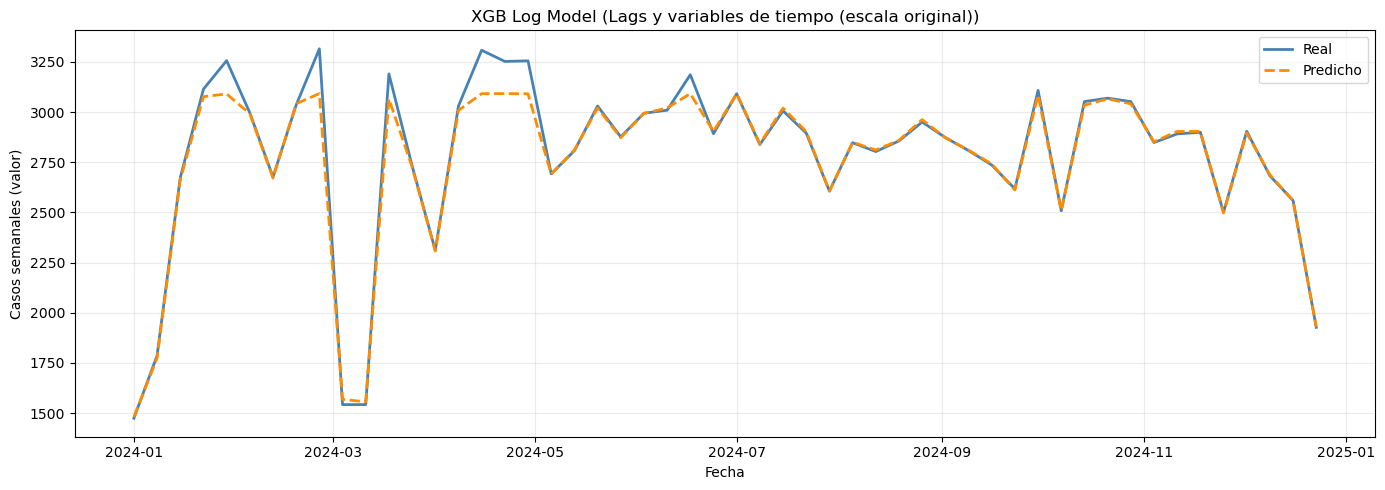

In [195]:
plot_last_year(
    df_xgb.iloc[-len(y_pred_test):],         
    y_real_test.values,   # valores reales
    y_pred_test,          # valores predichos
    title="XGB Log Model (Lags y variables de tiempo (escala original))"
)

,feature,gain
6,valor,0.410021
1,rolling_mean,0.001077
2,rolling_std,0.000570
3,upper_bound,0.000369
11,lag_12,0.000117
4,mes,0.000058
13,lag_52,0.000058
7,mes_sin,0.000050
10,lag_4,0.000025
12,lag_26,0.000018


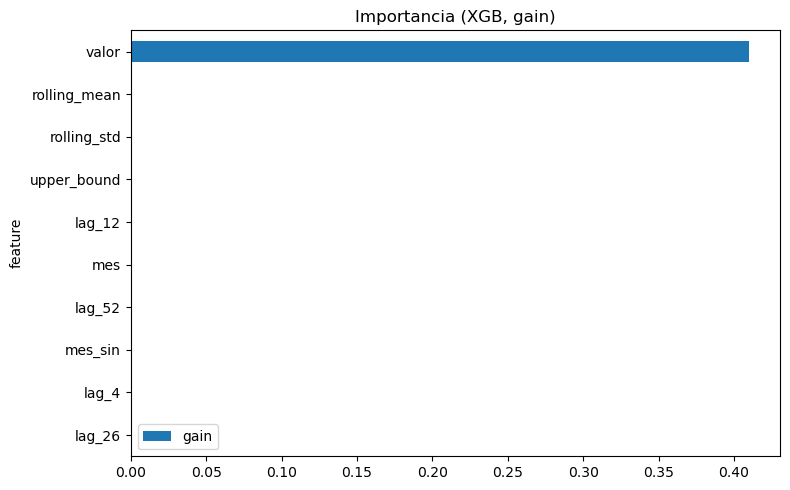

In [196]:

feature_importance_xgb(xgb_logmodel, features, top=10)

### Covid Model

In [197]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

In [198]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features_c = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

In [199]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

X_train = train_df[features_c]
y_train = train_df['y_log']
X_test  = test_df[features_c]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

In [200]:
# Parámetros
params3 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.08,              
    "max_depth": 10,           
    "min_child_weight": 5,   # hojas con más soporte
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "lambda": 1,             # L2 ↑
    "alpha": 2,               # L1 ↑
    "gamma": 0.001,             # penaliza splits débiles
    "seed": 42,
}

# Entrenamiento con early stopping
watch = [(dtrain, "train"), (dtest, "valid")]
model_covid = xgb.train(params3, dtrain,
                        num_boost_round=7000,
                        evals=watch,
                        early_stopping_rounds=500,
                        verbose_eval=200)

[0]	train-rmse:0.31428	valid-rmse:0.31524
[200]	train-rmse:0.12497	valid-rmse:0.14417
[400]	train-rmse:0.11728	valid-rmse:0.14424
[600]	train-rmse:0.11324	valid-rmse:0.14497
[656]	train-rmse:0.11210	valid-rmse:0.14506


In [201]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
mae_train = mean_absolute_error(y_real_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_real_train, y_pred_train))
mae_test = mean_absolute_error(y_real_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_real_test, y_pred_test))

print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

Train -> MAE=106.72  RMSE=152.33
Test  -> MAE=230.94  RMSE=343.74


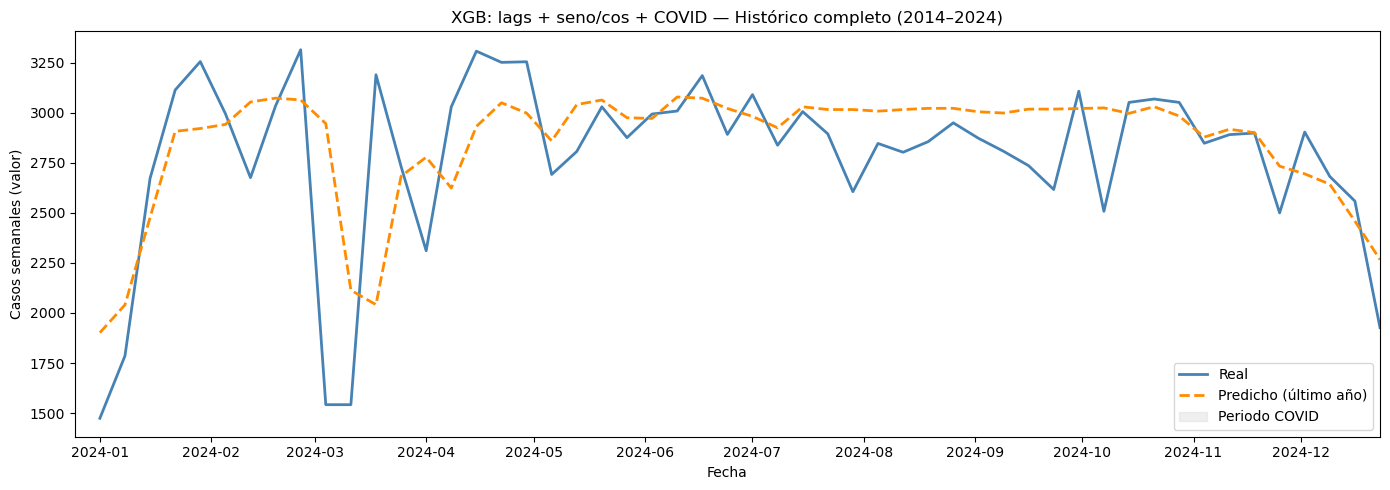

In [202]:
# Gráfico histórico completo
df_c['pred_log'] = np.nan
df_c.loc[df_c.index[-test_size]:, 'pred_log'] = model_covid.predict(xgb.DMatrix(X_test),
                                                                    iteration_range=(0, model_covid.best_iteration+1))
df_c['pred'] = np.expm1(df_c['pred_log'])
fechas_test = df_c['fecha'].iloc[-len(y_real_test):]

plt.figure(figsize=(14,5))
plt.plot(fechas_test, y_real_test.values, label='Real', color='steelblue', linewidth=2)
plt.plot(fechas_test, y_pred_test, '--', label='Predicho (último año)', color='darkorange', linewidth=2)
plt.axvspan(covid_start, covid_end, color='lightgray', alpha=0.35, label='Periodo COVID')
plt.xlim(df_c['fecha'].max() - pd.DateOffset(weeks=52), df_c['fecha'].max())
plt.title("XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.tight_layout(); plt.show()

,feature,gain
0,lag_1,0.465112
1,lag_4,0.051681
7,semanas_desde_covid,0.045423
6,mes_cos,0.039098
2,lag_12,0.032913
10,semana_cos,0.031148
9,semana_sin,0.030455
4,lag_52,0.029808
8,semana_del_año,0.023670
5,mes_sin,0.023037


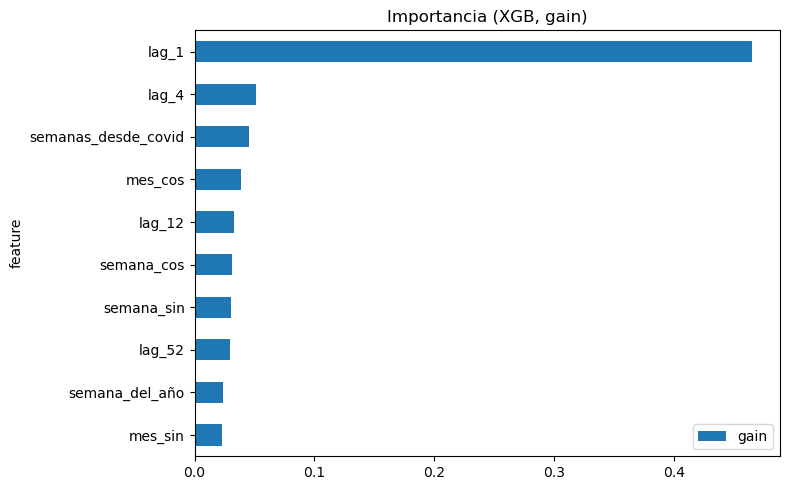

In [203]:
feature_importance_xgb(model_covid, features, top=10)

### Validacion termporal walk-forward 4x26

In [ ]:

mae_mean, rmse_mean, maes_list, rmses_list = walk_forward_eval(df_xgb, features, h=26, blocks=4, params=params1, verbose=True)
print(f"Walk-forward (4) Base Model: MAE={np.mean(maes_list):.2f} ± {np.std(maes_list):.2f} | RMSE={np.mean(rmses_list):.2f} ± {np.std(rmses_list):.2f}")

mae_mean, rmse_mean, maes_list, rmses_list = walk_forward_eval(df_xgb, features, h=26, blocks=4, params=params2, verbose=True)
print(f"Walk-forward (4) Log Model: MAE={np.mean(maes_list):.2f} ± {np.std(maes_list):.2f} | RMSE={np.mean(rmses_list):.2f} ± {np.std(rmses_list):.2f}")

mae_mean, rmse_mean, maes_list, rmses_list = walk_forward_eval(df_c, features, h=26, blocks=4, params=params3, verbose=True)
print(f"Walk-forward (4) Covid Model: MAE={np.mean(maes_list):.2f} ± {np.std(maes_list):.2f} | RMSE={np.mean(rmses_list):.2f} ± {np.std(rmses_list):.2f}")




Bloque 1 -> MAE=275.9 RMSE=353.1  (best_iter=3673)
Bloque 2 -> MAE=174.2 RMSE=318.5  (best_iter=2501)
Bloque 3 -> MAE=50.1 RMSE=87.4  (best_iter=2414)
Bloque 4 -> MAE=4.9 RMSE=6.7  (best_iter=2368)
Walk-forward (4): MAE=126.30 ± 106.34 | RMSE=191.44 ± 147.66
Bloque 1 -> MAE=275.9 RMSE=353.2  (best_iter=3111)
Bloque 2 -> MAE=174.4 RMSE=318.8  (best_iter=2838)
Bloque 3 -> MAE=49.9 RMSE=87.1  (best_iter=2910)
Bloque 4 -> MAE=4.9 RMSE=6.8  (best_iter=2363)
Walk-forward (4): MAE=126.28 ± 106.38 | RMSE=191.46 ± 147.75
Bloque 1 -> MAE=359.1 RMSE=428.7  (best_iter=5307)
Bloque 2 -> MAE=278.5 RMSE=399.3  (best_iter=5891)
Bloque 3 -> MAE=119.1 RMSE=165.7  (best_iter=5865)
Bloque 4 -> MAE=29.1 RMSE=36.5  (best_iter=612)
Walk-forward (4): MAE=196.43 ± 129.57 | RMSE=257.57 ± 163.30


## Random Forest

[RF Baseline - solo lags]
Train -> MAE=139.77  RMSE=203.74
Test  -> MAE=292.53  RMSE=402.88


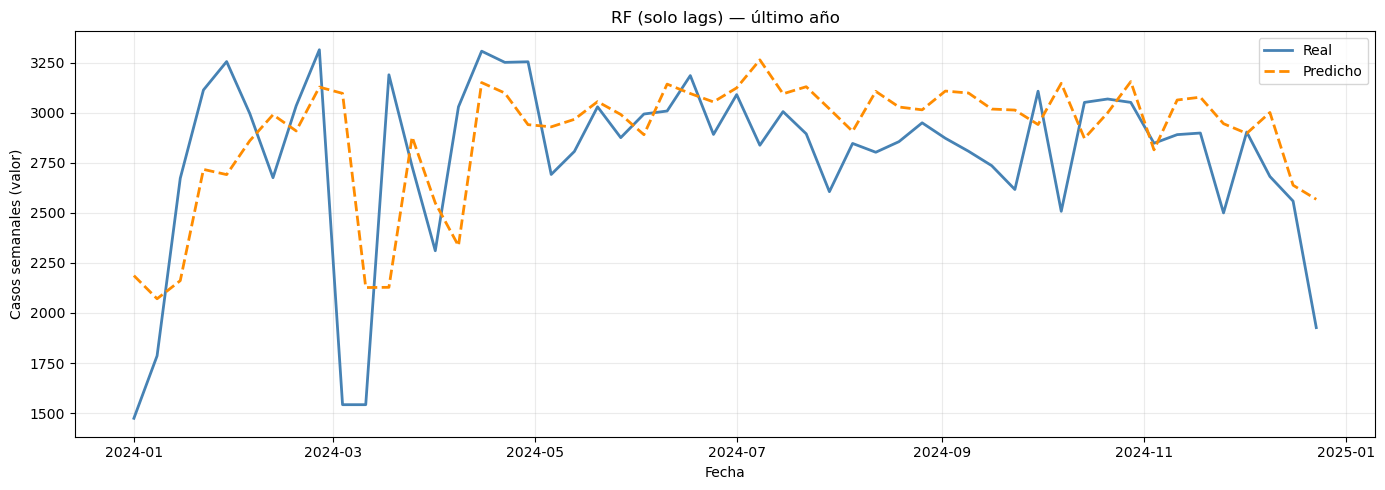

In [205]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,           
    min_samples_split=5,     
    min_samples_leaf=5,       
    max_features='sqrt',      
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF Baseline - solo lags]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")


### RF Model with sin + cos

[RF + seno/cos]
Train -> MAE=141.51  RMSE=206.44
Test  -> MAE=282.30  RMSE=391.10


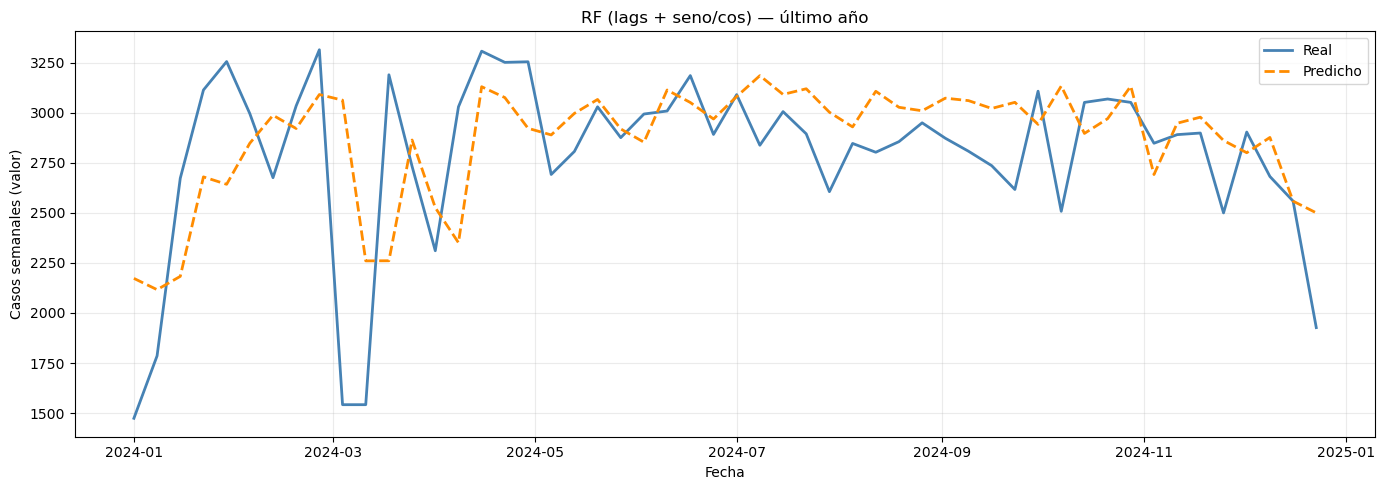

In [206]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

rf_seno = RandomForestRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + seno/cos]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos) — último año")


### Covid RF Model

[RF + COVID continuo]
Train -> MAE=143.87  RMSE=211.24
Test  -> MAE=281.50  RMSE=390.65


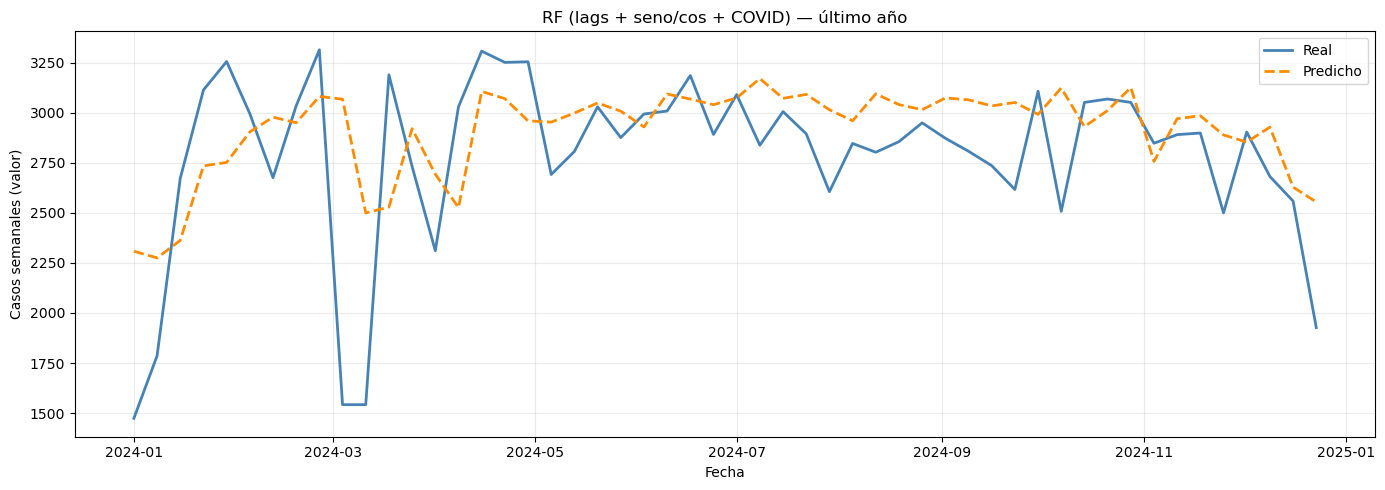

In [207]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

rf_covid = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + COVID continuo]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos + COVID) — último año")


### RF Model + rolling

[RF + rolling]
Train -> MAE=123.19  RMSE=185.52
Test  -> MAE=263.05  RMSE=362.84


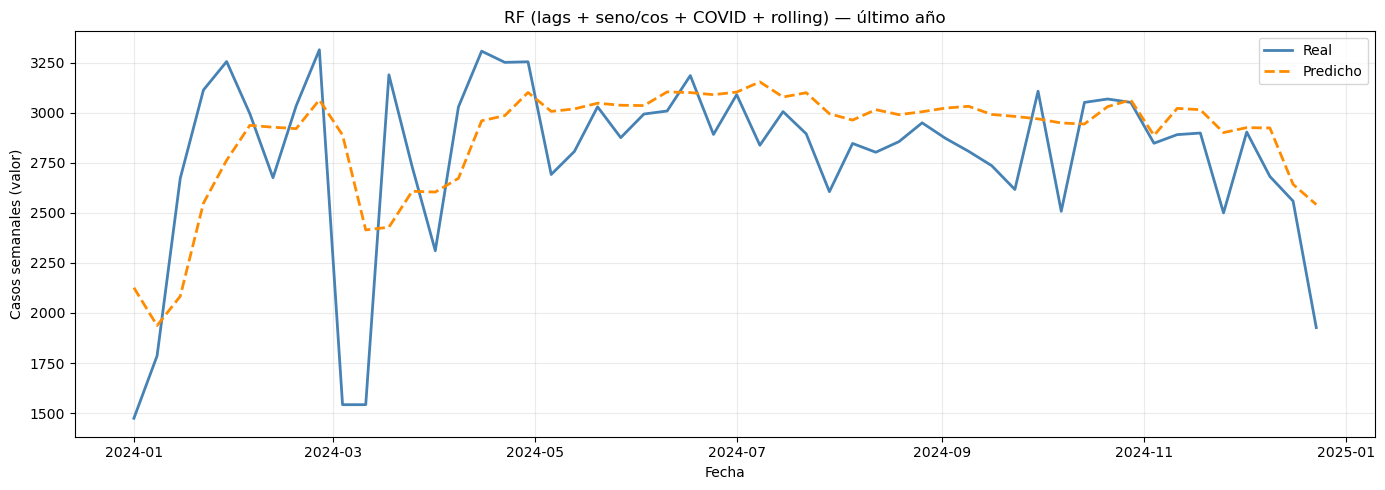

In [208]:

df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

rf_roll = RandomForestRegressor(
    n_estimators=900,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + rolling]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos + COVID + rolling) — último año")


### RF + tendencia y dummies (2020-2022)

[RF + tendencia + años]
Train -> MAE=128.33  RMSE=191.99
Test  -> MAE=260.51  RMSE=365.02


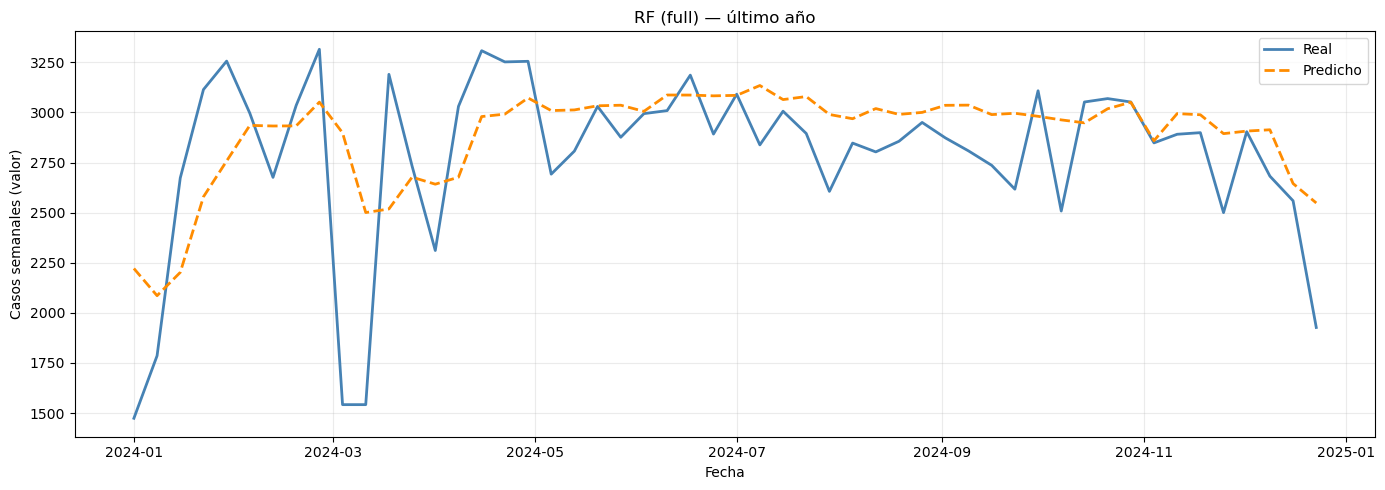

In [209]:

df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

rf_full = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,          # si ves sobreajuste, pon 20
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + tendencia + años]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (full) — último año")


### Walk forward

In [210]:
def walk_forward_cv(df, features, target, n_splits=4):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    maes, rmses = [], []
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        mae, rmse = eval_mae_rmse(y_te, y_hat)
        maes.append(mae); rmses.append(rmse)

    print(f"Walk-forward ({n_splits}): MAE={np.mean(maes):.2f} ± {np.std(maes):.2f} | RMSE={np.mean(rmses):.2f} ± {np.std(rmses):.2f}")


print("Base Model")
walk_forward_cv(df_rf4, features_lags, target, n_splits=4)

print("SIN/COS Model")
walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4)

print("Covid Model")
walk_forward_cv(df_rf3, features_covid, target, n_splits=4)

print("Rolling Model")
walk_forward_cv(df_rf4, features_rolling, target, n_splits=4)

print("Tendencia Model")
walk_forward_cv(df_rf5, features_full, target, n_splits=4)


Base Model
Walk-forward (4): MAE=316.18 ± 51.98 | RMSE=384.36 ± 56.22
SIN/COS Model
Walk-forward (4): MAE=328.86 ± 59.21 | RMSE=395.75 ± 63.06
Covid Model
Walk-forward (4): MAE=377.47 ± 46.58 | RMSE=446.88 ± 40.00
Rolling Model
Walk-forward (4): MAE=271.02 ± 46.20 | RMSE=332.44 ± 47.76
Tendencia Model
Walk-forward (4): MAE=316.09 ± 50.71 | RMSE=378.28 ± 48.06


[RF Full + RollingLong]
Train -> MAE=93.58  RMSE=144.75
Test  -> MAE=228.27  RMSE=321.18


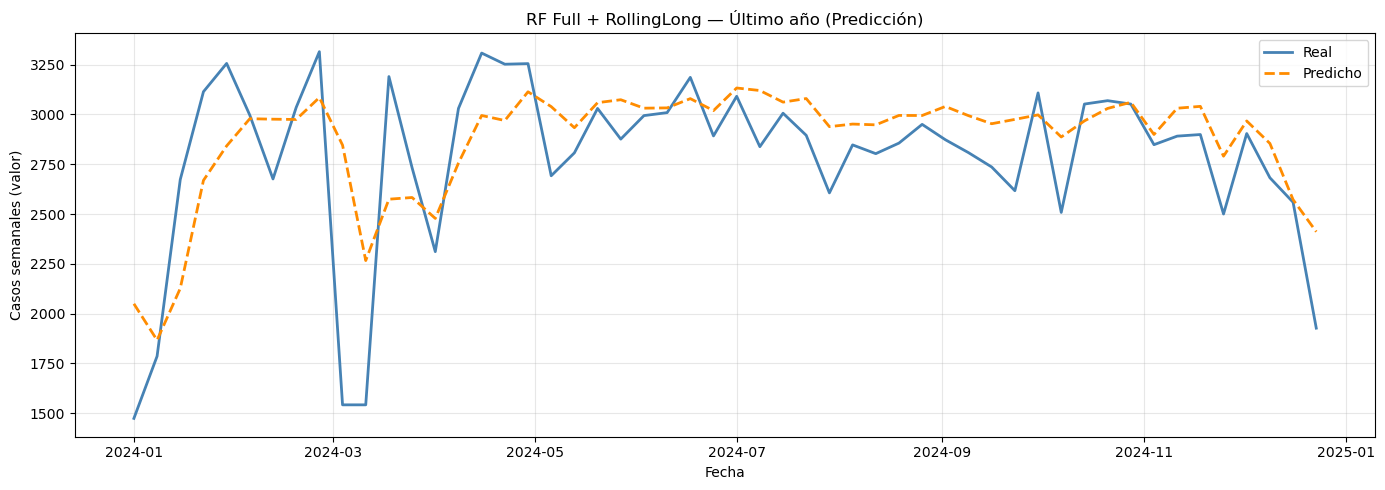

In [211]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

rf_full_long = RandomForestRegressor(
    n_estimators=1200,      # más árboles = mejor estabilidad
    max_depth=18,           # control de complejidad
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_train)
mae_te, rmse_te = eval_mae_rmse(y_test, y_pred_test)

print(f"[RF Full + RollingLong]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plt.figure(figsize=(14,5))
plt.plot(test_df["fecha"], y_test, label="Real", color="steelblue", linewidth=2)
plt.plot(test_df["fecha"], y_pred_test, "--", label="Predicho", color="darkorange", linewidth=2)
plt.title("RF Full + RollingLong — Último año (Predicción)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [212]:
print("Longer Rolling Model")
walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4)

Longer Rolling Model
Walk-forward (4): MAE=272.96 ± 47.83 | RMSE=326.08 ± 50.56


### RF + XGBoost

[0]	train-rmse:515.17667	valid-rmse:719.88136


[200]	train-rmse:43.21146	valid-rmse:324.06133
[336]	train-rmse:26.75377	valid-rmse:323.17863
[XGBoost Full + RollingLong]
Train -> MAE=12.31  RMSE=26.72
Test  -> MAE=239.17  RMSE=323.16


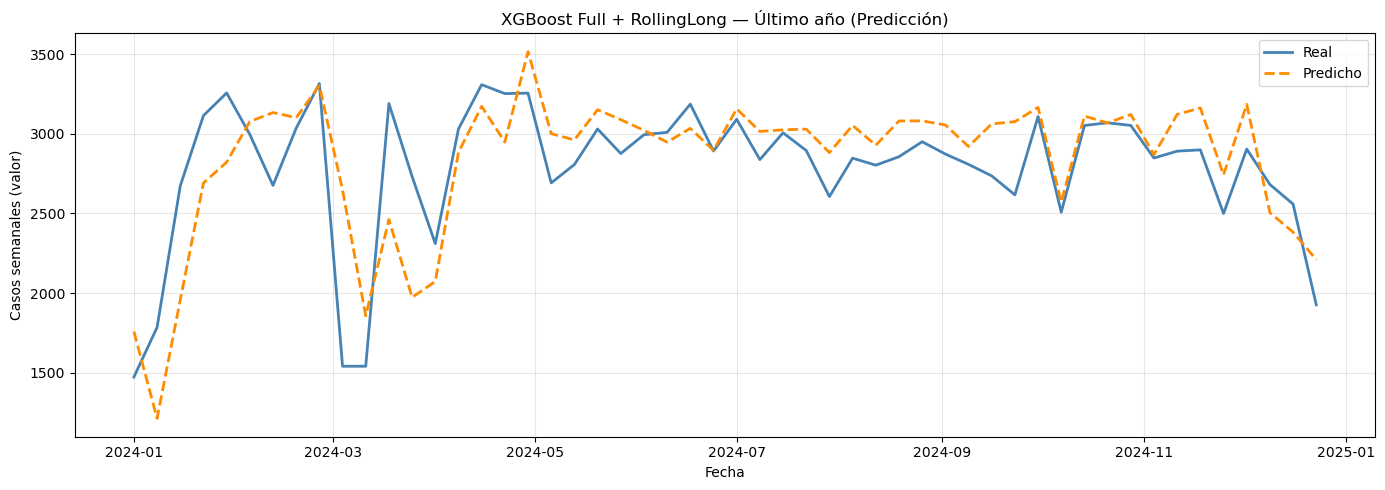


🔎 Top 10 variables más importantes:
                feature          gain
8             rolling_4  1.366973e+06
0                 lag_1  1.147971e+05
13              trend_8  9.758113e+04
7   semanas_desde_covid  6.584941e+04
10           rolling_12  4.632332e+04
11           rolling_26  3.489629e+04
9             rolling_8  2.725838e+04
4                lag_52  2.621088e+04
14             año_2020  2.490264e+04
12            tendencia  2.408671e+04


In [213]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,              
    "max_depth": 10,
    "min_child_weight": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1,
    "alpha": 1,
    "gamma": 0.1,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"[XGBoost Full + RollingLong]")
print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

plt.figure(figsize=(14,5))
plt.plot(test_df["fecha"], y_test, label="Real", color="steelblue", linewidth=2)
plt.plot(test_df["fecha"], y_pred_test, "--", label="Predicho", color="darkorange", linewidth=2)
plt.title("XGBoost Full + RollingLong — Último año (Predicción)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

importance = model_xgb_full.get_score(importance_type="gain")
importance_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "gain": list(importance.values())
}).sort_values(by="gain", ascending=False)

print("\n🔎 Top 10 variables más importantes:")
print(importance_df.head(10))

In [214]:
print("XGB + Rolling Model")
walk_forward_cv(df_xgb, features_full_long, target, n_splits=4)

XGB + Rolling Model
Walk-forward (4): MAE=272.96 ± 47.83 | RMSE=326.08 ± 50.56


## Long Short Term Memory